### Transformada rápida de Fourier para $N$ qualquer
### 1. Motivação

A função fft_2() que implementamos só funciona quando o comprimento do sinal é potência de 2, pois o bit-reversal e a divisão em pares/ímpares dependem disso.

Na prática, porém, sinais raramente têm comprimento potência de 2. O algoritmo de Bluestein resolve isso: ele reescreve a DFT de qualquer $N$ como uma convolução, que pode ser calculada rapidamente usando nossa FFT_2, bastando um zero-padding até a próxima potência de 2. O resultado ainda tem complexidade $\mathcal{O}(N\log_2 N)$, mesmo para $N$ que não é potência de 2.

### 2. DFT e Convolução 

Partimos da definição da DFT:

$$X(k) = \sum_{n=0}^{N-1} x(n)\,e^{-j\frac{2\pi}{N}kn}$$

O truque de Bluestein usa a identidade algébrica:

$$\boxed{kn = \frac{k^2+n^2-(k-n)^2}{2}}$$

Substituindo no expoente, o produto $kn$ vira uma soma de três termos independentes:

$$e^{-j\frac{2\pi}{N}kn} = e^{-j\frac{\pi}{N}k^2}\cdot e^{-j\frac{\pi}{N}n^2}\cdot e^{\,j\frac{\pi}{N}(k-n)^2}$$

Substituindo de volta em $X(k)$ e agrupando o que depende só de $k$, só de $n$, e de $(k-n)$:

$$X(k) = e^{-j\frac{\pi}{N}k^2} \sum_{n=0}^{N-1} \underbrace{\left[x(n)\,e^{-j\frac{\pi}{N}n^2}\right]}_{a(n)} \cdot \underbrace{e^{\,j\frac{\pi}{N}(k-n)^2}}_{b(k-n)}$$

Definindo o sinal *chirp* $c(n) = e^{-j\frac{\pi}{N}n^2}$, temos $a(n) = x(n)\,c(n)$ e $b(n) = c(n)^{*} = e^{\,j\frac{\pi}{N}n^2}$. O somatório é exatamente uma convolução linear:

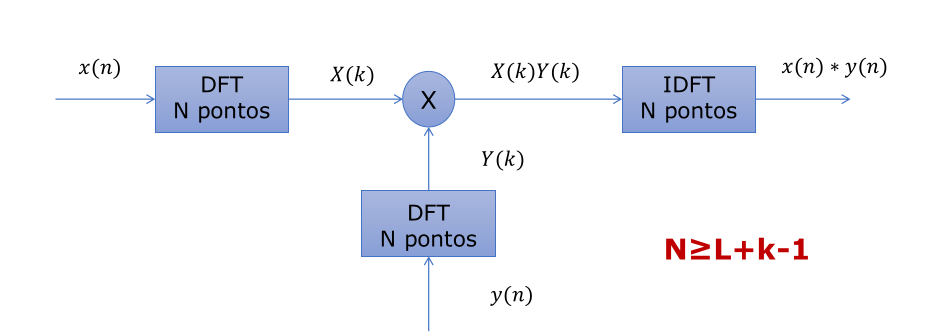
<p style="text-align:center; font-size:0.9em; color:white;">
Fonte: VELOSO, Luciana Ribeiro. <i>Processamento Digital de Sinais</i>
</p>

$$\boxed{X(k) = c(k)\cdot (a * b)(k), \qquad (a*b)(k) = \sum_{n} a(n)\,b(k-n)}$$

### 3. Calculando a Convolução com a FFT.

Convoluções lineares podem ser calculadas rapidamente via DFT/FFT, desde que se use zero-padding suficiente. Como vimos nas propriedades da DFT, se $x(n)$ e $v(n)$ sequência com comprimentos $L$ e $M$, respectivamente. A convolução circular dado por $ x(n) \bigotimes_{}^{} v(n) $ é equivalente se:
$$\boxed{N \geq L + M - 1}$$

Aqui, $a(n)$ e $b(n)$ têm efetivamente comprimento $N$ e $2N-1$ (pois $b$ precisa de índices negativos, de $-(N-1)$ a $N-1$), então escolhemos:

$$M = \text{próxima potência de 2} \;\geq\; N + (2N-1) -1 = 3N - 2 \equiv 2N -1 $$

Com $a$ e $b$ preenchidos com zeros até $M$ pontos, a convolução linear é obtida por:

$$a * b \;=\; \text{IFFT}\big(\text{FFT}(a)\cdot \text{FFT}(b)\big)$$

### 4. Implementação

Reaproveitamos as funções da fft_2() e acrescentando mais algumas temos:

- **ifft**: a FFT inversa, obtida reaproveitando a própria fft com o truque do conjugado: $\text{IFFT}(X) = \dfrac{1}{N}\Big(\text{FFT}(X^{*})\Big)^{*}$
- **proxima_potencia_de_2**: menor potência de 2 maior ou igual a um valor dado.

In [1]:
# Importando bibliotecas.
import numpy as np
import matplotlib.pyplot as plt
import time

In [2]:
def bit_reversal(x):
    """
    Função para realizar a inversão dos indices das amostras.
    
    Solução:
    invertido = texto[::-1] --> 001 --> 100
    """
    
    N = len(x)
    x_invertido = np.zeros(N, dtype = complex)
    num_bits = int(np.log2(N))
    
    # Iniciando o laço para realizar a inversão.
    for i in range (N):
        
        # Transformando o indice em texto binário.
        indice = f"{i:0{num_bits}b}"
        
        # Inverte a ordem dos textos do indice.
        inverte = indice[::-1]
        
        # Converter para inteiro binário.
        indice = int(inverte,2)
        
        # Insere o valor da amostra original ao novo indice.
        x_invertido[indice] = x[i]
        
    return x_invertido, num_bits

In [3]:
def fft_2(x_in):
    """
    Função para realizar a DFT iterativa (fft).
    Exige que len(x) seja potência de 2.
    
    Solução:
    Usando o metodo borboleta, conseguimos reduzir a complexidade da DFT.
    """
    
    N = len(x_in)
    x, num_bits = bit_reversal(x_in) 
    
    for i in range (num_bits):
        
        # 1° laço: Iniciando todo o processo definindo o tamanho do bloco inicial.
        tamanho_bloco = 2 ** (1 + i)
        metade_bloco  = tamanho_bloco // 2
        
        for inicio_par in range (0, N, tamanho_bloco):
            
            # 2° laço: Determina o inicio do bloco, onde se encontra os valores pares.
            
            for k in range (metade_bloco):
                
                # 3° laço: Motor do metódo borboleta.
                indice_par = inicio_par + k
                indice_impar = inicio_par + k + metade_bloco
                a = x[indice_par]
                b = x[indice_impar]
                w = np.exp(-1j*(2*np.pi / tamanho_bloco)*k)
                c = w*b
                           
                x_positivo = a + c
                x_negativo = a - c
                
                x[indice_par] = x_positivo
                x[indice_impar] = x_negativo
                            
    return x

In [4]:
def ifft(X):
    """
    Propriedade da IFFT.
    
    IFFT(X) = (1/N) * conjugado( FFT( conjugado(X) ) )
    """
    
    N = len(X)
    x = fft_2(np.conjugate(X))
    x = np.conjugate(x) / N
    
    return x

In [5]:
def proxima_potencia_de_2(N):
    """
    Função para encontrar a próxima potência de 2 maior ou igual a N.
    """
    
    potencia = 1
    while potencia < N:
        potencia *= 2
        
    return potencia

### 5. FFT com Algoritmo de Bluestein

Fórmula:

$$X(k) = c(k)\cdot(a*b)(k), \qquad c(n) = e^{-j\frac{\pi}{N}n^2} , \qquad (a*b)(k) = \sum_{n} a(n)\,b(k-n)$$

Gera-se o chirp $c(n)$ e as sequências $a(n) = x(n)c(n)$ e $b(n) = c(n)^{*}$;

In [6]:
def fft(x_in, N=None):
    """
    Função para realizar a FFT de um sinal de comprimento N qualquer,
    usando o algoritmo de Bluestein (Chirp-Z Transform).
    """
    
    x_in = np.array(x_in, dtype=complex)
    L = len(x_in)
    
    if N is None:
        N = L
    
    # Verifica condição N >= L (evita time aliasing)
    if N < L:
        raise ValueError(f"N={N} deve ser >= L={L} para evitar time aliasing!")
    
    # Zero-padding: se N > L, completa com zeros até comprimento N
    if N > L:
        x_in = np.concatenate([x_in, np.zeros(N - L, dtype=complex)])
    
    # Caso N já seja potência de 2.
    if (N & (N - 1)) == 0:
        return fft_2(x_in)
    
    # Índices do sinal.
    n = np.arange(N)
    
    # Sinal chirp: c(n) = exp(-j*pi*n^2/N).
    chirp = np.exp((-1j * np.pi * (n**2)) / N)
    
    # Sequências a(n) e b(n) da convolução.
    a = x_in * chirp
    b = np.conjugate(chirp)
    
    # M = próxima potência de 2 >= 2N-1.
    M = proxima_potencia_de_2(2*N - 1)
    
    # Preenchendo a com zeros até M pontos.
    a_pad = np.zeros(M, dtype=complex)
    a_pad[:N] = a
    
    # Preenchendo b com zeros, posicionando os índices negativos no final
    b_pad = np.zeros(M, dtype=complex)
    b_pad[:N] = b
    b_pad[M-N+1:] = b[1:][::-1]
    
    # Convolução linear via FFT: a*b = IFFT( FFT(a) . FFT(b) ).
    A = fft(a_pad)
    B = fft(b_pad)
    conv = ifft(A * B)
    
    # Multiplica pelo chirp e mantém apenas os N primeiros pontos.
    X = chirp * conv[:N]
    
    return X

### 6. Custo Computacional

Cada etapa do algoritmo de Bluestein geração do chirp, duas FFTs poteência de 2 de tamanho $M$, uma multiplicação ponto a ponto e uma IFFT custa $\mathcal{O}(M\log_2 M)$.

$$\boxed{\text{Complexidade: } \mathcal{O}(N\log_2 N)}$$

In [7]:
def medir_tempo_fft_qualquer_N(x, N):
    """
    Recebe um sinal x qualquer e mede o tempo da FFT para N qualquer (Bluestein).
    """
    x = np.array(x, dtype=complex)

    t0 = time.time()
    X = fft(x, N)
    t_fft = (time.time() - t0) * 1000

    print(f"Tamanho do sinal:  N = {N}")
    print(f"FFT (Bluestein):      {t_fft:.4f} ms")

    return X

In [9]:
print("=== Implementação da FFT para N qualquer (Bluestein) ===")
print("Digite os valores das amostras separados por espaço (ex: 0 1 2 3):")

L = int(input("Quantidade de amostras do sinal (L): "))
N = int(input("Número de pontos da FFT (N >= L, qualquer valor): "))

np.random.seed(42)
x = np.random.randn(L)

X = medir_tempo_fft_qualquer_N(x, N=N)

print(f"\n=== Saída da FFT ({N} pontos) ===")

if len(X) > 10:
    t = 10
else:
    t = len(X)

for i in range(t):
    print(f"  X[{i}] = {X[i]:.2f}")

=== Implementação da FFT para N qualquer (Bluestein) ===
Digite os valores das amostras separados por espaço (ex: 0 1 2 3):
Tamanho do sinal:  N = 1024
FFT (Bluestein):      6.8030 ms

=== Saída da FFT (1024 pontos) ===
  X[0] = 30.08+0.00j
  X[1] = 29.15+8.67j
  X[2] = -30.28+34.26j
  X[3] = -14.00+22.97j
  X[4] = -34.86-9.42j
  X[5] = 25.65+13.12j
  X[6] = -1.41-2.54j
  X[7] = 27.36-17.36j
  X[8] = 8.44+20.10j
  X[9] = 9.46+29.13j


In [10]:
import json

tamanhos = [16, 32, 64, 128, 256, 512, 1024, 2048]
REPETICOES = 5

tempos_bluestein = []

for N in tamanhos:
    np.random.seed(42)
    x = np.random.randn(N)
    medicoes = []
    for _ in range(REPETICOES):
        t0 = time.time()
        fft(x)
        medicoes.append((time.time() - t0) * 1000)
    media_blu = round(float(np.mean(medicoes)), 4)
    tempos_bluestein.append(media_blu)
    print(f"N = {N:5d} → {media_blu:.4f} ms")
    
metricas = {
    "nome"       : "FFT Bluestein",
    "tamanhos"   : tamanhos,
    "tempos_ms"  : tempos_bluestein
}

with open("fft_geral_metrics.json", "w") as f:
    json.dump(metricas, f, indent=2)

print("\nSalvo em fft_geral_metrics.json.")

N =    16 → 0.0284 ms
N =    32 → 0.0501 ms
N =    64 → 0.1392 ms
N =   128 → 0.2268 ms
N =   256 → 0.5008 ms
N =   512 → 1.1732 ms
N =  1024 → 2.5623 ms
N =  2048 → 5.4504 ms

Salvo em fft_geral_metrics.json.


## Referências

**Wikipedia Contributors.** *Chirp Z-transform and Bluestein's Algorithm.* Wikipedia, The Free Encyclopedia. Disponível em: https://en.wikipedia.org/wiki/Chirp_Z-transform#Bluestein.27s_algorithm